# Potts model

Step 1: Define Q states with values 1, 2, ..., Q.

In [33]:
# import ipynb
# %run problem_set_5.ipynb
# %run problem_set_6.ipynb

import random
import math
import matplotlib.pyplot as plt
import numpy as np

In [34]:
def get_states_potts(Q):
    return [i for i in range(1, Q + 1)]

def get_states_candidate_potts(Q, old_spin):
    return [s for s in get_states_potts(Q) if s != old_spin]

Step 2: Initialize the starting configuration:

+ Cold: All spins set to 1.

+ Random: Each spin randomly assigned a value from 1 to Q with uniform distribution.

In [35]:
def generate_lattice_potts(N, Q, mode):
    if mode == 'cold':
        return [[1 for _ in range(N)] for _ in range(N)]
    elif mode == 'random':
        return [[random.choice(get_states_potts(Q)) for _ in range(N)] for _ in range(N)]
    
# print(generate_lattice_potts(5, 3, 'random'))

Step 3: Run the Metropolis and Wolff cluster algorithms for the Potts model, similar to the Ising model.

For spin flips, propose a new, different random value from 1 to Q.

Formulas to compute energy and magnetization:

+ Energy: $$ E= - \sum_{<i,j>} \delta_{s_i s_j}$$
where $<i,j>$ denotes neighboring pairs.

+ Magnetization: 
$$ M = \dfrac{Q}{Q-1} \bigl( \dfrac{N_{max}}{N^2} - \dfrac{1}{Q}\bigr)$$
where $N$ is the lattice size, $N_{max}$  is the count of the most frequent spin state in the lattice. 


### 3.0 Energy & Magnetization

In [36]:
def compute_total_energy_potts(lattice, N):
    E_total = 0

    for i in range(N):
        for j in range(N):
            spin = lattice[i][j]
            s_right = lattice[i][(j+1) % N]
            s_down = lattice[(i+1) % N][j]
            
            if spin == s_right:
                E_total -= 1
            if spin == s_down:
                E_total -= 1

    return E_total

def compute_total_magnetization_potts(lattice, N, Q):
    spin_occ = {}

    for row in lattice:
        for spin in row:
            if spin not in spin_occ:
                spin_occ[spin] = 0
            spin_occ[spin] += 1

    max_occ = max(spin_occ.values())
    mgn = (Q / (Q - 1)) * ((max_occ / (N * N)) - (1 / Q))

    return mgn

### 3.1 - Metropolis

In [37]:
# Computes change in energy of the system  if we change the spin.
# 1. Compute kronecker's delta for all 4 neighbors of both spins.
# 2. Compute initial and final energy and their difference as energy delta .
def compute_change_in_energy_Mpotts(lattice, N, old_spin, new_spin, i, j):
    old_sum = 0
    new_sum = 0

    # 2:
    for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
        if lattice[id][jd] == old_spin:
            old_sum += 1
        if lattice[id][jd] == new_spin:
            new_sum += 1

    # 3:
    E_old = -old_sum
    E_new = -new_sum

    return E_new - E_old

# Generates new configuration and based on the energy change dacides to flip the spin or not.
# 1. Randomly select a new spin different from the current one.
# 2. Compute the change in energy if we flip the spin at (i, j).
# 3. Decide whether to flip the spin based on the Metropolis criterion.
def generate_new_configuration_Mpotts(lattice, N, Q, i, j, beta):
    old_spin = lattice[i][j]

    # 1:
    new_spin = random.choice(get_states_candidate_potts(Q, old_spin))

    # 2:
    dE = compute_change_in_energy_Mpotts(lattice, N, old_spin, new_spin, i, j)

    # 3:
    if dE <= 0:
        lattice[i][j] = new_spin
    else:
        p = random.random()
        if p < math.exp(-beta * dE):
            lattice[i][j] = new_spin

# Runs the simulation of the Potts model using the Metropolis algorithm.
# 1. Initialize the lattice based on the specified mode (cold or random).
# 2. Perform a burn-in phase.
# 3. Perform measurement steps, compute energy and magnetization.
# 4. Compute and return mean energy and magnetization.
def simulate_Mpotts(N, Q, mode, beta, burn_in_steps=1000, measure_steps=2000):

    # 1:
    lattice = generate_lattice_potts(N, Q, mode)

    # 2:
    for _ in range(burn_in_steps):
        for _ in range(N**2):
            i = random.randint(0, N-1)
            j = random.randint(0, N-1)
            generate_new_configuration_Mpotts(lattice, N, Q, i, j, beta)

    E = []
    M = []

    # 3:
    for _ in range(measure_steps):
        for _ in range(N * N):
            i = random.randint(0, N-1)
            j = random.randint(0, N-1)
            generate_new_configuration_Mpotts(lattice, N, Q, i, j, beta)

        e = compute_total_energy_potts(lattice, N)
        m = compute_total_magnetization_potts(lattice, N, Q)

        E.append(e)
        M.append(m)

    # 4:
    mean_E = sum(E) / len(E)
    mean_M = sum(M) / len(M)

    return E, M, mean_E, mean_M

### 3.2 Wolff Clusters

In [38]:
# Try to add a spin to cluster.
# 1. If the spin is different than the type we create cluster for then it stops.
# 2. If the spin is the same but already in cluster, it stops.
# 3. If the spin is the same and not in cluster, it adds to cluster with probability p_add and checks all neighbors of this spin.
# Recursion stops when all neighbors of the cluster are checked and are either:
#    - different type, or
#    - the same type but already in cluster, or
#    - the same type and not in cluster but not added to cluster.
def try_add_to_cluster_Wpotts(lattice, N, i, j, original_spin, p_add, cluster):
    
    # 1:
    if lattice[i][j] != original_spin:
        return
    
    # 2:
    if (i, j) in cluster:
        return
    
    # 3:
    if random.random() < p_add:
        cluster.add((i, j))
        for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
                try_add_to_cluster_Wpotts(lattice, N, id, jd, original_spin, p_add, cluster)

# Creates a cluster of spins using Wolff algorithm.
# 1. Chooses random seed spin.
# 2. Creates cluster with seed spin already in it.
# 3. Checks all neighbors of the seed spin and tries to add them to the cluster.
def create_cluster_Wpotts(lattice, N, p_add):

    # 1:
    i = random.randint(0, N-1)
    j = random.randint(0, N-1)
    spin = lattice[i][j]

    # 2:
    cluster = {(i, j)}

    # 3:
    for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
        try_add_to_cluster_Wpotts(lattice, N, id, jd, spin, p_add, cluster)

    return cluster

# Flips all spins in the cluster.
# 1. Calculates probability of adding a spin to the cluster.
# 2. Creates cluster of spins using Wolff algorithm.
# 3. Chooses new spin different from the one in the cluster.
# 4. Flips all spins in the cluster to the new spin.
def flip_cluster_Wpotts(lattice, N, Q, beta):

    # 1:
    p_add = 1.0 - math.exp(-beta)

    # 2:
    cluster = create_cluster_Wpotts(lattice, N, p_add)

    # 3:
    i, j = next(iter(cluster))
    old_spin = lattice[i][j]
    new_spin = random.choice(get_states_candidate_potts(Q, old_spin))

    # 4:
    for i, j in cluster:
        lattice[i][j] = new_spin

# Runs the simulation of the Ising model using Wolff algorithm.
# 1. Creates initial configuration of the lattice.
# 2. Runs burn in phase - don't collect data on steps.
# 3. Runs measurement phase - computes total energy and magnetization after each step.
# 4. Computes mean energy and magnetization.
def simulate_Wpotts(N, Q, mode, beta, burn_in_steps=1000, measure_steps=2000):

    # 1:
    lattice = generate_lattice_potts(N, Q, mode)

    # 2:
    for _ in range(burn_in_steps):
        flip_cluster_Wpotts(lattice, N, Q, beta)

    E = []
    M = []

    # 3:
    for _ in range(measure_steps):
        flip_cluster_Wpotts(lattice, N, Q, beta)

        e = compute_total_energy_potts(lattice, N)
        m = compute_total_magnetization_potts(lattice, N, Q)
        E.append(e)
        M.append(abs(m))

    # 4:
    mean_E = sum(E) / len(E)
    mean_M = sum(M) / len(M)

    return E, M, mean_E, mean_M

# Task
Plot magnetization and energy of Potts model as a function of $\beta$ near $\beta_c = \ln(1+ \sqrt{Q})$ using Metropolis and Wolff cluster.

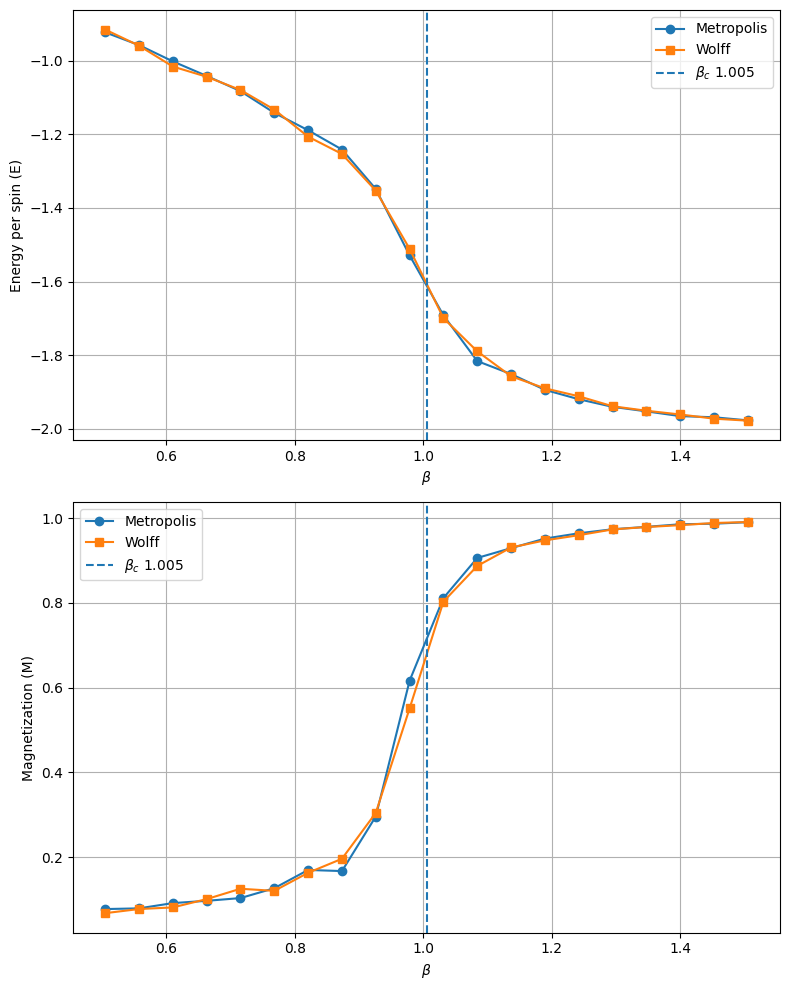

In [39]:
# Visualization of Potts 
# 1. Parameters of the simulation.
# 2. Define beta range around critical point.
# 3. Run simulations for both algorithms and collect data.
# 4: Plot energy and magnetization as a function of beta.

# 1:
N = 16
Q = 3
delta = 0.5

# 2:
beta_c = math.log(1 + math.sqrt(Q))
betas = np.linspace(beta_c - delta, beta_c + delta, 20)

E_metropolis, M_metropolis = [], []
E_wolff, M_wolff = [], []

# 3:
for beta in betas:
    # 3.1 - Metropolis:
    _, _, mean_E_m, mean_M_m = simulate_Mpotts(N, Q, 'random', beta, burn_in_steps=500, measure_steps=1000)
    E_metropolis.append(mean_E_m / (N * N))
    M_metropolis.append(mean_M_m)
    
    # 3.2 - Wolff:
    _, _, mean_E_w, mean_M_w = simulate_Wpotts(N, Q, 'random', beta, burn_in_steps=500, measure_steps=1000)
    E_wolff.append(mean_E_w / (N * N))
    M_wolff.append(mean_M_w)

# 4:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

# 4.1 - Energy plot:
ax1.plot(betas, E_metropolis, 'o-', label='Metropolis')
ax1.plot(betas, E_wolff, 's-', label='Wolff')
ax1.axvline(beta_c, linestyle='--', label=rf'$\beta_c ~ {beta_c:.3f}$')
ax1.set_xlabel(r'$\beta$')
ax1.set_ylabel('Energy per spin (E)')
ax1.legend()
ax1.grid(True)

# 4.2 - Magnetization plot:
ax2.plot(betas, M_metropolis, 'o-', label='Metropolis')
ax2.plot(betas, M_wolff, 's-', label='Wolff')
ax2.axvline(beta_c, linestyle='--', label=rf'$\beta_c ~ {beta_c:.3f}$')
ax2.set_xlabel(r'$\beta$')
ax2.set_ylabel('Magnetization (M)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()